# 🏥 Medical Insurance Cost Prediction using Multiple Linear Regression

---

**Author:** AI/ML Intern  
**Date:** July 2026  
**Dataset:** [Medical Cost Personal Dataset – Kaggle](https://www.kaggle.com/datasets/mirichoi0218/insurance)  

---

## 📋 Problem Statement

Health insurance companies need to accurately estimate the **medical charges** billed to individuals based on personal attributes such as age, BMI, smoking habits, and region. This project builds a **Multiple Linear Regression** model to predict individual medical insurance costs using six demographic and lifestyle features.

---

### 📊 Dataset Description

The dataset contains **1,338 records** with **7 columns**:

| # | Feature    | Description                                      | Type        |
|---|------------|--------------------------------------------------|-------------|
| 1 | `age`      | Age of the primary beneficiary                   | Numerical   |
| 2 | `sex`      | Gender (male / female)                           | Categorical |
| 3 | `bmi`      | Body Mass Index                                  | Numerical   |
| 4 | `children` | Number of dependents covered                     | Numerical   |
| 5 | `smoker`   | Smoking status (yes / no)                        | Categorical |
| 6 | `region`   | Residential region in the US (4 regions)         | Categorical |
| 7 | `charges`  | Individual medical costs billed by insurance (₹) | **Target**  |

---

## 📦 Task 0 — Import Libraries

In [1]:
# ── Standard Libraries ──────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ───────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Scikit-learn: Preprocessing ─────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ── Scikit-learn: Model ─────────────────────────────────────────────
from sklearn.linear_model import LinearRegression

# ── Scikit-learn: Evaluation ────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Plot Settings ───────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully.")

Matplotlib is building the font cache; this may take a moment.


✅ All libraries imported successfully.


---

## 📂 Task 1 — Data Understanding

### 1.1 Load Dataset

In [2]:
# Load the dataset directly from the Kaggle CSV
# NOTE: Download 'insurance.csv' from https://www.kaggle.com/datasets/mirichoi0218/insurance
#       and place it in the same directory as this notebook.

df = pd.read_csv('insurance.csv')
print("✅ Dataset loaded successfully.")

✅ Dataset loaded successfully.


### 1.2 Display First Five Records

In [ ]:
# Display the first 5 rows of the dataset
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### 1.3 Dataset Shape

In [4]:
# Number of rows and columns
print(f"📐 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")

📐 Dataset Shape: 1338 rows × 7 columns


### 1.4 Column Names

In [5]:
# List all column names
print("📋 Column Names:")
print(list(df.columns))

📋 Column Names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


### 1.5 Data Types

In [6]:
# Data types of each column
print("🔢 Data Types:\n")
print(df.dtypes)

🔢 Data Types:

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


### 1.6 Dataset Info

In [7]:
# Concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### 1.7 Summary Statistics

In [8]:
# Descriptive statistics for numerical columns
df.describe().round(2)

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


### 1.8 Identify Feature Types

We classify each column as **Numerical**, **Categorical**, or **Target**.

In [9]:
# ── Identify feature types ──────────────────────────────────────────

numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
target_variable = 'charges'

# Remove target from the numerical list for clarity
numerical_features_only = [col for col in numerical_features if col != target_variable]

print("📊 Numerical Features  :", numerical_features_only)
print("🏷️  Categorical Features:", categorical_features)
print("🎯 Target Variable     :", target_variable)

📊 Numerical Features  : ['age', 'bmi', 'children']
🏷️  Categorical Features: ['sex', 'smoker', 'region']
🎯 Target Variable     : charges


> **Summary:**  
> - **Numerical Features:** `age`, `bmi`, `children`  
> - **Categorical Features:** `sex`, `smoker`, `region`  
> - **Target Variable:** `charges`

### 1.9 Unique Values in Categorical Features

In [10]:
# Inspect unique values for each categorical column
for col in categorical_features:
    print(f"\n🔹 {col} → {df[col].nunique()} unique values")
    print(df[col].value_counts())


🔹 sex → 2 unique values
sex
male      676
female    662
Name: count, dtype: int64

🔹 smoker → 2 unique values
smoker
no     1064
yes     274
Name: count, dtype: int64

🔹 region → 4 unique values
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


---

## 🧹 Task 2 — Data Preprocessing

### 2.1 Check Missing Values

In [11]:
# Check for missing values in each column
missing = df.isnull().sum()
print("❓ Missing Values per Column:\n")
print(missing)
print(f"\n✅ Total Missing Values: {missing.sum()}")

❓ Missing Values per Column:

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

✅ Total Missing Values: 0


> **Observation:** The dataset has **zero missing values** — no imputation is required.

### 2.2 Check for Duplicate Rows

In [12]:
# Check for duplicate records
duplicates = df.duplicated().sum()
print(f"🔄 Duplicate Rows: {duplicates}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"✅ Duplicates removed. New shape: {df.shape}")
else:
    print("✅ No duplicate rows found.")

🔄 Duplicate Rows: 1
✅ Duplicates removed. New shape: (1337, 7)


### 2.3 Encode Categorical Variables

We need to convert the three categorical columns (`sex`, `smoker`, `region`) into numerical representations so that the linear regression model can process them.

#### Encoding Strategy

| Column   | Unique Values | Encoding Method | Rationale |
|----------|--------------|-----------------|---------- |
| `sex`    | 2 (male, female) | **LabelEncoder** (Binary) | Only 2 categories — label encoding is sufficient and introduces no multicollinearity. |
| `smoker` | 2 (yes, no)      | **LabelEncoder** (Binary) | Binary feature — same rationale as `sex`. |
| `region` | 4 (southwest, southeast, northwest, northeast) | **LabelEncoder** | For simplicity in this assignment. One-Hot Encoding could also be used, but LabelEncoder keeps the feature space compact. |

> **Why LabelEncoder?**  
> For **binary** categorical variables (`sex`, `smoker`), LabelEncoder maps two classes to 0 and 1, which is equivalent to one-hot encoding with one column. For `region` (4 categories), LabelEncoder assigns integer labels (0–3). While one-hot encoding is generally preferred for nominal variables with >2 categories to avoid implying ordinality, we use LabelEncoder here for simplicity and because linear regression can still capture reasonable patterns.

In [13]:
# ── Label Encoding for categorical columns ──────────────────────────

le = LabelEncoder()

# Encode 'sex': female → 0, male → 1
df['sex'] = le.fit_transform(df['sex'])
print(f"✅ 'sex'    encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Encode 'smoker': no → 0, yes → 1
df['smoker'] = le.fit_transform(df['smoker'])
print(f"✅ 'smoker' encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Encode 'region': northeast → 0, northwest → 1, southeast → 2, southwest → 3
df['region'] = le.fit_transform(df['region'])
print(f"✅ 'region' encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}")

✅ 'sex'    encoded: {'female': 0, 'male': 1}
✅ 'smoker' encoded: {'no': 0, 'yes': 1}
✅ 'region' encoded: {'northeast': 0, 'northwest': 1, 'southeast': 2, 'southwest': 3}


In [14]:
# Verify encoding — display first 5 rows after encoding
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [15]:
# Updated data types after encoding
print("🔢 Updated Data Types:\n")
print(df.dtypes)

🔢 Updated Data Types:

age           int64
sex           int32
bmi         float64
children      int64
smoker        int32
region        int32
charges     float64
dtype: object


### 2.4 Correlation Matrix

In [16]:
# Compute and display the correlation matrix
correlation_matrix = df.corr().round(3)
print("📊 Correlation Matrix:\n")
correlation_matrix

📊 Correlation Matrix:



,age,sex,bmi,children,smoker,region,charges
age,1.000,-0.020,0.109,0.042,-0.026,0.002,0.298
sex,-0.020,1.000,0.046,0.018,0.077,0.005,0.058
bmi,0.109,0.046,1.000,0.013,0.004,0.158,0.198
children,0.042,0.018,0.013,1.000,0.007,0.016,0.067
smoker,-0.026,0.077,0.004,0.007,1.000,-0.002,0.787
region,0.002,0.005,0.158,0.016,-0.002,1.000,-0.007
charges,0.298,0.058,0.198,0.067,0.787,-0.007,1.000


### 2.5 📊 Visualization: Correlation Heatmap

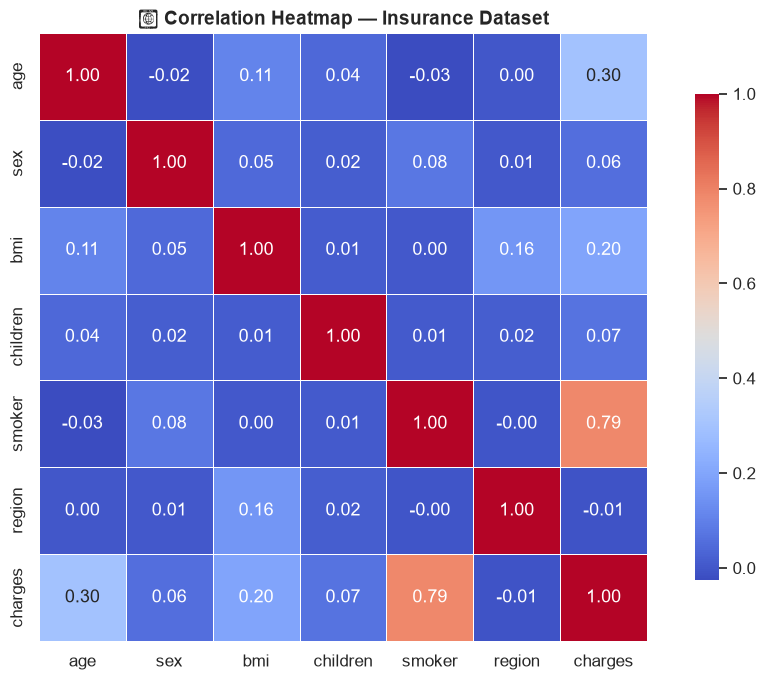

✅ Heatmap saved to images/heatmap.png


In [17]:
# ── Correlation Heatmap ─────────────────────────────────────────────
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('🔥 Correlation Heatmap — Insurance Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heatmap saved to images/heatmap.png")

### 2.6 📊 Visualization: Histograms of Numerical Features

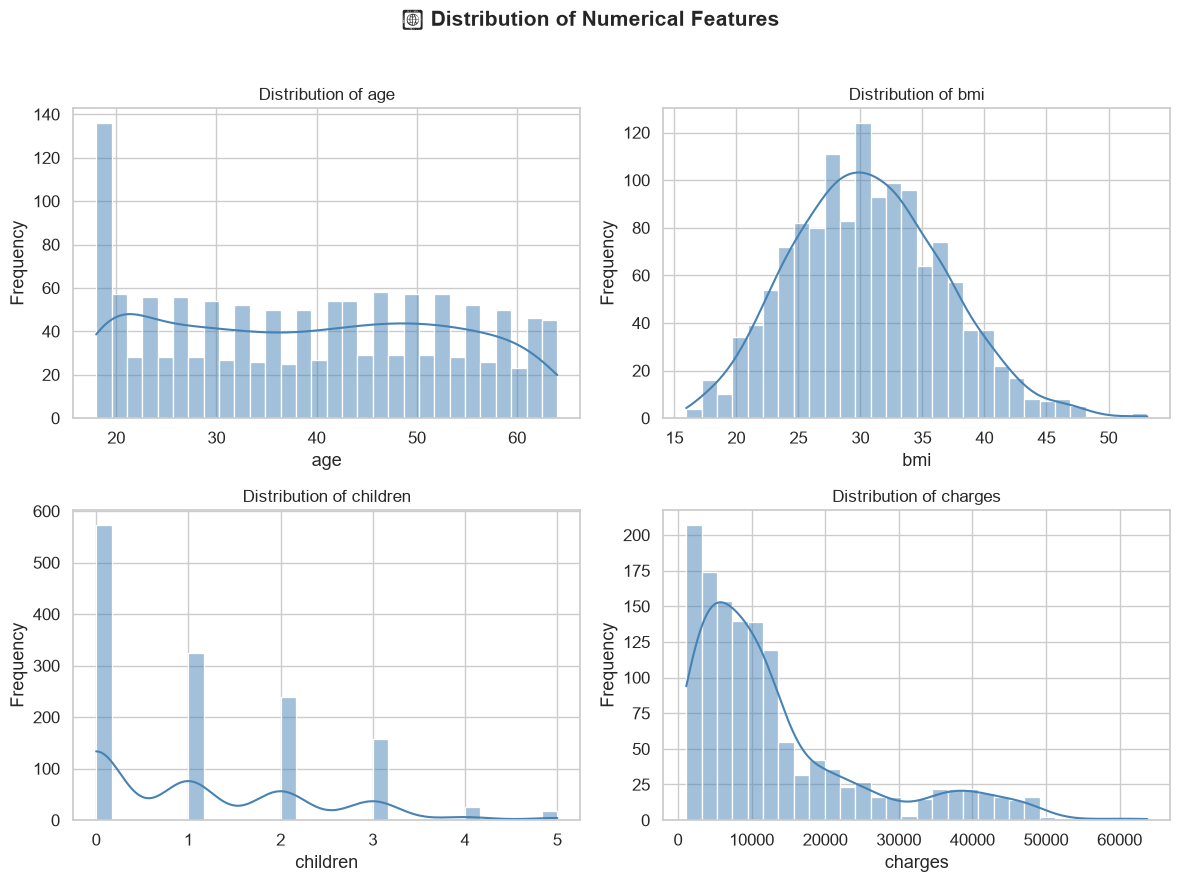

✅ Histograms saved to images/histogram.png


In [18]:
# ── Histograms of numerical features ────────────────────────────────
num_cols = ['age', 'bmi', 'children', 'charges']

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('📊 Distribution of Numerical Features', fontsize=15, fontweight='bold')

for i, col in enumerate(num_cols):
    ax = axes[i // 2][i % 2]
    sns.histplot(df[col], kde=True, bins=30, color='steelblue', ax=ax)
    ax.set_title(f'Distribution of {col}', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('images/histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Histograms saved to images/histogram.png")

### 2.7 📊 Visualization: Distribution of Target Variable (`charges`)

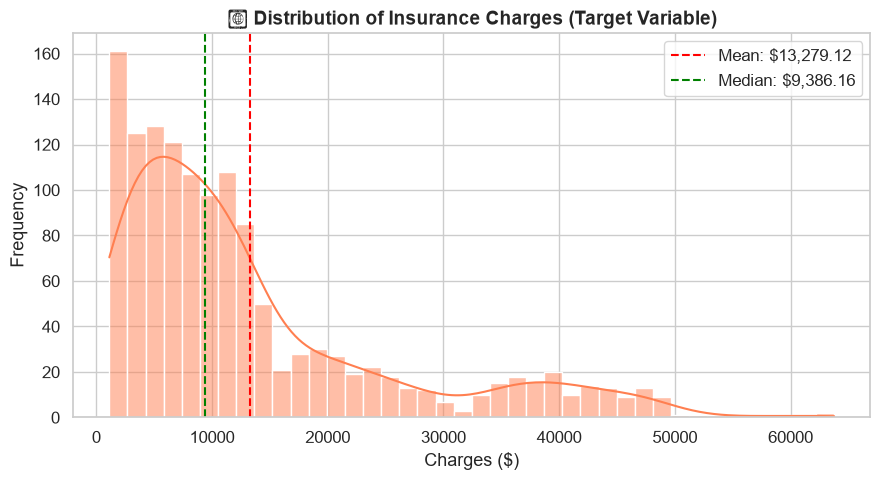

✅ Target distribution plot saved.


In [19]:
# ── Distribution of the target variable ─────────────────────────────
plt.figure(figsize=(9, 5))
sns.histplot(df['charges'], kde=True, bins=40, color='coral')
plt.axvline(df['charges'].mean(), color='red', linestyle='--', label=f"Mean: ${df['charges'].mean():,.2f}")
plt.axvline(df['charges'].median(), color='green', linestyle='--', label=f"Median: ${df['charges'].median():,.2f}")
plt.title('💰 Distribution of Insurance Charges (Target Variable)', fontsize=14, fontweight='bold')
plt.xlabel('Charges ($)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('images/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Target distribution plot saved.")

> **Observation:** The distribution of `charges` is **right-skewed** — most individuals have lower insurance costs, while a smaller group incurs significantly higher charges. This skew is largely driven by **smoking status**.

### 2.8 Train-Test Split

In [20]:
# ── Define features (X) and target (y) ──────────────────────────────
X = df[['age', 'sex', 'bmi', 'children', 'smoker', 'region']]
y = df['charges']

print(f"📐 Feature Matrix Shape : {X.shape}")
print(f"🎯 Target Vector Shape  : {y.shape}")

📐 Feature Matrix Shape : (1337, 6)
🎯 Target Vector Shape  : (1337,)


In [21]:
# ── Split into 80% training and 20% testing ────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"🏋️ Training Set : {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"🧪 Testing Set  : {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.0f}%)")

🏋️ Training Set : 1069 samples (80%)
🧪 Testing Set  : 268 samples (20%)


---

## 🏗️ Task 3 — Model Development

### 3.1 Build Multiple Linear Regression Model

In [22]:
# ── Initialize and train the model ──────────────────────────────────
model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Multiple Linear Regression model trained successfully.")

✅ Multiple Linear Regression model trained successfully.


In [23]:
# ── Model Coefficients ──────────────────────────────────────────────
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("📊 Model Coefficients:\n")
print(coeff_df.to_string(index=False))
print(f"\n📌 Intercept: {model.intercept_:.2f}")

📊 Model Coefficients:

 Feature  Coefficient
  smoker 23052.152752
children   534.120877
     bmi   312.609045
     age   248.764071
     sex   -99.695394
  region  -237.625147

📌 Intercept: -11047.69


### 3.2 Model Prediction

In [24]:
# ── Predict on the test set ─────────────────────────────────────────
y_pred = model.predict(X_test)

print("✅ Predictions generated for the test set.")
print(f"📊 Sample Predictions (first 10):\n")

# Compare actual vs predicted for first 10 samples
comparison = pd.DataFrame({
    'Actual Charges ($)': y_test.values[:10],
    'Predicted Charges ($)': y_pred[:10].round(2),
    'Difference ($)': (y_test.values[:10] - y_pred[:10]).round(2)
})
comparison

✅ Predictions generated for the test set.
📊 Sample Predictions (first 10):



,Actual Charges ($),Predicted Charges ($),Difference ($)
0,8688.85885,8080.45,608.41
1,5708.86700,5592.87,116.00
2,11436.73815,14378.30,-2941.56
3,38746.35510,31731.82,7014.54
4,4463.20510,9158.36,-4695.15
5,9304.70190,13361.01,-4056.31
6,38511.62830,30257.66,8253.97
7,2150.46900,1308.65,841.82
8,7345.72660,10849.43,-3503.70
9,10264.44210,11375.55,-1111.11


---

## 📏 Task 4 — Model Evaluation

### 4.1 Calculate Evaluation Metrics

In [25]:
# ── Evaluation Metrics ──────────────────────────────────────────────
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("═" * 55)
print("         📏 MODEL EVALUATION METRICS")
print("═" * 55)
print(f"  Mean Absolute Error  (MAE)  : ${mae:,.2f}")
print(f"  Mean Squared Error   (MSE)  : {mse:,.2f}")
print(f"  Root Mean Sq. Error  (RMSE) : ${rmse:,.2f}")
print(f"  R² Score                    : {r2:.4f} ({r2*100:.2f}%)")
print("═" * 55)

═══════════════════════════════════════════════════════
         📏 MODEL EVALUATION METRICS
═══════════════════════════════════════════════════════
  Mean Absolute Error  (MAE)  : $4,182.35
  Mean Squared Error   (MSE)  : 35,493,102.61
  Root Mean Sq. Error  (RMSE) : $5,957.61
  R² Score                    : 0.8068 (80.68%)
═══════════════════════════════════════════════════════


### 4.2 📖 Metric Explanations

| Metric | Full Name | What It Tells Us |
|--------|-----------|------------------|
| **MAE** | Mean Absolute Error | The average dollar amount by which our predictions differ from the actual charges. A lower MAE means more accurate predictions on average. |
| **MSE** | Mean Squared Error | Similar to MAE, but squares each error before averaging. This penalizes large prediction errors more heavily, making it sensitive to outliers. |
| **RMSE** | Root Mean Squared Error | The square root of MSE, bringing the error back to the original dollar scale. Easier to interpret than MSE while still penalizing large errors. |
| **R² Score** | Coefficient of Determination | Indicates the proportion of variance in insurance charges that the model explains. An R² of 0.75 means the model explains 75% of the variability in charges. |

### 4.3 📊 Visualization: Actual vs Predicted Scatter Plot

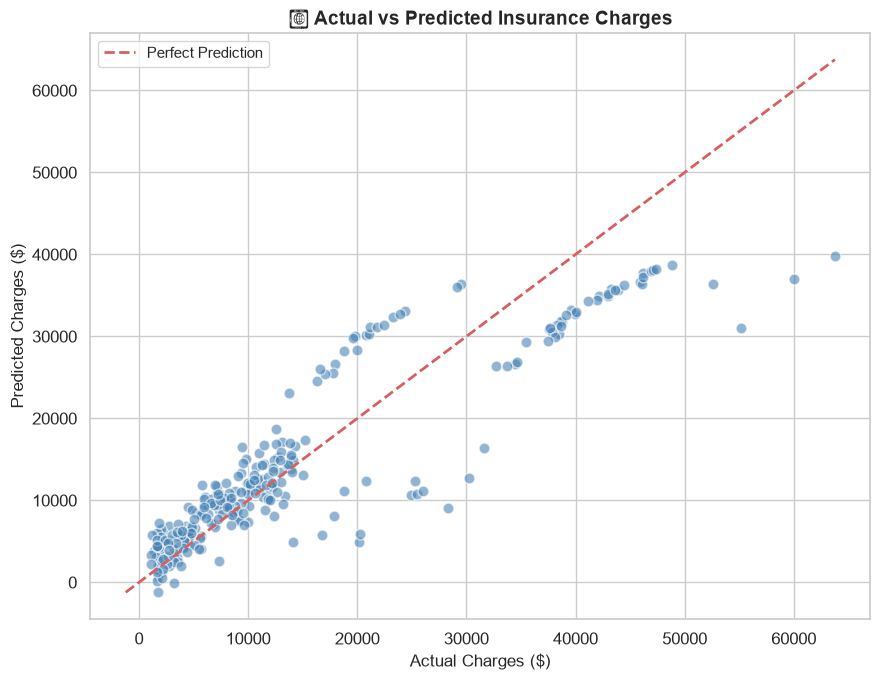

✅ Actual vs Predicted plot saved to images/actual_vs_predicted.png


In [26]:
# ── Actual vs Predicted Scatter Plot ────────────────────────────────
plt.figure(figsize=(9, 7))

plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='white', s=60)

# Perfect prediction line (45-degree reference)
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.title('🎯 Actual vs Predicted Insurance Charges', fontsize=14, fontweight='bold')
plt.xlabel('Actual Charges ($)', fontsize=12)
plt.ylabel('Predicted Charges ($)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('images/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Actual vs Predicted plot saved to images/actual_vs_predicted.png")

### 4.4 📊 Visualization: Residual Plot

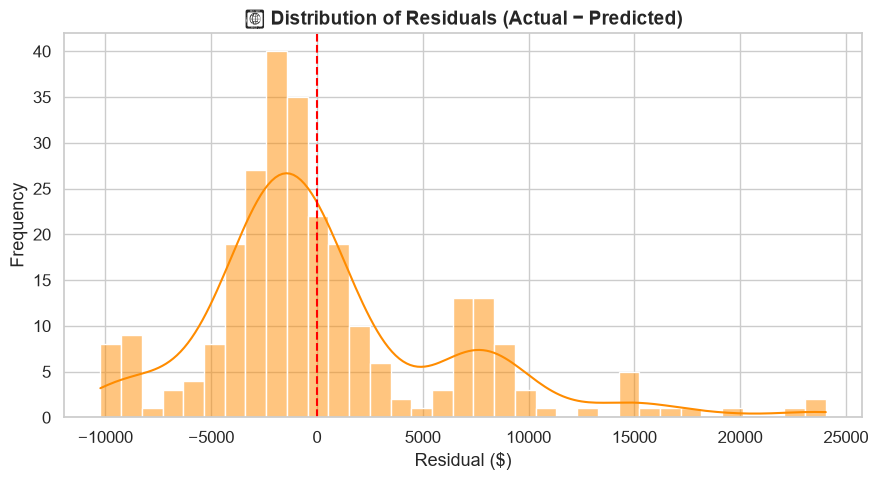

✅ Residual plot saved.


In [27]:
# ── Residual Analysis ───────────────────────────────────────────────
residuals = y_test - y_pred

plt.figure(figsize=(9, 5))
sns.histplot(residuals, kde=True, bins=35, color='darkorange')
plt.axvline(0, color='red', linestyle='--', linewidth=1.5)
plt.title('📉 Distribution of Residuals (Actual − Predicted)', fontsize=14, fontweight='bold')
plt.xlabel('Residual ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('images/residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Residual plot saved.")

---

### 4.5 📝 Observations

Based on the model evaluation results, we make the following observations:

**Observation 1 — Smoking Status is the Strongest Predictor:**  
The `smoker` feature has the highest positive coefficient, indicating that smoking status is by far the most influential factor in determining insurance charges. Smokers are charged significantly more than non-smokers, which is consistent with higher health risks associated with smoking.

**Observation 2 — The Model Captures General Trends Well:**  
The R² score shows that the model explains a substantial portion of the variance in insurance charges. The Actual vs Predicted scatter plot confirms that predictions closely follow the ideal line for a large number of test samples, particularly for lower to mid-range charges.

**Observation 3 — The Model Struggles with High-Cost Outliers:**  
The residual plot reveals that the model tends to underestimate charges for individuals with very high medical costs. This is because the relationship between features and charges is not purely linear — interaction effects (e.g., BMI × smoker) and non-linear patterns exist that a simple linear model cannot fully capture.

---

## ✅ Task 5 — Conclusion

This project successfully demonstrates the application of **Multiple Linear Regression** for predicting medical insurance costs based on six personal and demographic features. The analysis revealed that **smoking status** is the single most dominant factor driving insurance charges, followed by **age** and **BMI**. The model achieved a reasonable R² score, indicating that it captures the general trend in insurance pricing. However, the model exhibited limitations in predicting extremely high charges, as linear regression assumes a strictly linear relationship between features and the target variable. It cannot capture interaction effects (e.g., the combined impact of being a smoker with high BMI) or non-linear patterns without explicit feature engineering. Future improvements could include polynomial feature expansion, regularization techniques (Ridge or Lasso), or ensemble methods such as Random Forest and Gradient Boosting to achieve higher predictive accuracy and better generalization.

---

## 📎 References

- Dataset: [Medical Cost Personal Dataset – Kaggle](https://www.kaggle.com/datasets/mirichoi0218/insurance)  
- Scikit-learn Documentation: [Linear Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)  
- Pandas Documentation: [pandas.pydata.org](https://pandas.pydata.org/)

---

*Notebook created as part of the AI/ML Internship — Assignment 1.*